# 💧 LFM2 - Antidoom Training with TRL

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Liquid4All/cookbook/blob/main/finetuning/notebooks/antidoom_with_trl.ipynb)

This tutorial demonstrates how to run the [Antidoom](https://github.com/Liquid4All/antidoom) training pipeline on our LFM models, e.g., `LiquidAI/LFM2.5-1.2B-Base`, using the TRL library.

Small reasoning models can get stuck in so-called **doom loops**, which are repetitive patterns where the model repeats the same phrase over and over until the context window is exhausted without reaching an answer. The Antidoom approach reduces doom loops with **Final Token Preference Optimization (FTPO)** training without affecting the model's reasoning ability.

## 🎯 What You'll Find:
- **Doom loop detection** — Identify repetitive generation patterns
- **FTPO pair extraction** — Build single-token preference training data
- **FTPOTrainer** — A [DPOTrainer subclass](https://huggingface.co/docs/trl/main/en/customization#change-the-training-objective) that trains one token position at a time
- **Before/after evaluation** — Measure doom loop reduction

## 📋 Prerequisites:
- **GPU Runtime**: Select GPU in `Runtime` → `Change runtime type`
- **Hugging Face Account**: For accessing models and datasets

# 📦 Installation & Setup

First, let's install all the required packages:


In [1]:
!pip install -qU "transformers>=5.11.0" "trl>=1.5.1" "peft>=0.15.2" "torchao>=0.16.0" "datasets>=2.19" matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 116.4 MB/s eta 0:00:00


Let's now verify the packages are installed correctly

In [2]:
import torch
import transformers
import trl

print(f"📦 PyTorch version: {torch.__version__}")
print(f"🤗 Transformers version: {transformers.__version__}")
print(f"📊 TRL version: {trl.__version__}")

📦 PyTorch version: 2.11.0+cu128
🤗 Transformers version: 5.17.0
📊 TRL version: 1.13.0


In [3]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

# Loading the model from Transformers 🤗

Before applying Antidoom training to your model, make sure your model actually doom loops.
Doom loops are most common in **small models that generate long chain-of-thought reasoning**. Small models without reasoning capabilities typically don't produce the extended outputs where doom loops occur and larger models with reasoning capabilities tend to not get stuck in doom loops.

Note, that some of the LFM models have already undergone Antidoom training (including LFM2.5-1.2B-Instruct, LFM2.5-1.2B-Thinking, LFM2.5-2.6B, and newer).

In this tutorial, we use [`LiquidAI/LFM2.5-1.2B-Base`](https://huggingface.co/LiquidAI/LFM2.5-1.2B-Base) as our base model.

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Model to fine-tune
model_id = "LiquidAI/LFM2.5-1.2B-Base"

print("📚 Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("🧠 Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype="auto",
)

print("✅ Model loaded successfully!")
print(f"🔢 Parameters: {model.num_parameters():,}")
print(f"📖 Vocab size: {len(tokenizer)}")
print(f"💾 Model size: ~{model.num_parameters() * 2 / 1e9:.1f} GB (bfloat16)")

📚 Loading tokenizer...


config.json:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/91.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.73M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ Model loaded successfully!
🔢 Parameters: 1,170,340,608
📖 Vocab size: 64400
💾 Model size: ~2.3 GB (bfloat16)


# 🔄 What is a Doom Loop?

Doom loops are a failure mode in reasoning models where the generation gets stuck in exact repetition of the same text block multiple times (e.g., four times or more), consuming the entire token budget without producing an answer.

For example, a model solving a math problem might start repeating:

```
...Let me reconsider. Wait, actually...Let me reconsider. Wait, actually...
```

We use a fingerprint-based repetition detector adapted from [`antidoom/repetition.py`](https://github.com/Liquid4All/antidoom/blob/main/src/antidoom/repetition.py) to identify these patterns. It slides a small fingerprint window across the text, and when two matching fingerprints are found, it verifies whether the gap between them is a repeating period.

Below you can see one example of a generation with a doom loop and one without.

In [5]:
# Adapted from https://github.com/Liquid4All/antidoom/blob/main/src/antidoom/repetition.py
from dataclasses import dataclass

@dataclass(frozen=True)
class RepeatHit:
    start: int
    end: int
    period: int
    repeats: int
    snippet: str

    @property
    def repeat_start(self):
        return self.start + self.period

def _verify_repetition_at(text, start_pos, period, min_repeats, min_total_repeated):
    if period < 1 or start_pos < 0 or start_pos + period > len(text):
        return False, None
    pattern = text[start_pos : start_pos + period]
    reps = 0
    pos = start_pos
    while pos + period <= len(text) and text[pos : pos + period] == pattern:
        reps += 1
        pos += period
    end_pos = pos
    pos = start_pos - period
    while pos >= 0 and text[pos : pos + period] == pattern:
        reps += 1
        start_pos = pos
        pos -= period
    total = reps * period
    if reps >= min_repeats and total >= min_total_repeated:
        snippet = pattern if len(pattern) <= 100 else pattern[:100] + "..."
        return True, RepeatHit(start_pos, end_pos, period, reps, snippet)
    return False, None

def find_inner_repetition(
    text,
    min_repeats=4,
    max_period=1024,
    min_period=1,
    min_total_repeated=60,
    sample_len=16,
    sample_interval=128,
):
    if not text or len(text) < min_total_repeated:
        return False, None
    n = len(text)
    for sample_pos in range(0, n - sample_len, sample_interval):
        fingerprint = text[sample_pos : sample_pos + sample_len]
        for other_pos in [
            text.find(fingerprint, sample_pos + sample_len),
            text.rfind(fingerprint, 0, sample_pos),
        ]:
            if other_pos == -1:
                continue
            candidate_period = abs(other_pos - sample_pos)
            if min_period <= candidate_period <= max_period:
                found, hit = _verify_repetition_at(
                    text, min(sample_pos, other_pos), candidate_period,
                    min_repeats=min_repeats, min_total_repeated=min_total_repeated,
                )
                if found:
                    return True, hit
    return False, None

In [6]:
# Test 1: Doom loop
doom_output = (
    "Let me think step by step. Consider the base case. "
    "Wait, let me reconsider this approach. "
    "Wait, let me reconsider this approach. "
    "Wait, let me reconsider this approach. "
    "Wait, let me reconsider this approach. "
)

found, hit = find_inner_repetition(doom_output)
print("Example doom loop output:")
print(doom_output[:150] + "...")
print(f"\n🔄 Doom loop detected: {found}")
print(f"   Repeating pattern: '{hit.snippet}'")
print(f"   Repeats: {hit.repeats} times")

# Test 2: No doom loop
clean_output = "Let me think step by step. First, 2+2=4. Then 4*3=12. So the answer is 12."

found, _ = find_inner_repetition(clean_output)
print(f"\n✅ Clean output — doom loop detected: {found}")

Example doom loop output:
Let me think step by step. Consider the base case. Wait, let me reconsider this approach. Wait, let me reconsider this approach. Wait, let me reconsid...

🔄 Doom loop detected: True
   Repeating pattern: ' Wait, let me reconsider this approach.'
   Repeats: 4 times

✅ Clean output — doom loop detected: False


# 🎯 Final Token Preference Optimization (FTPO + LoRA)

FTPO is the [Antidoom](https://github.com/Liquid4All/antidoom) training recipe that eliminates **doom loops** with a surgical, single-token intervention:
1. **Detect** doom loops in the model's own generations
2. **Extract** the one token where the loop starts and find ~20 plausible alternatives
3. **Train** a [DPOTrainer subclass](https://huggingface.co/docs/trl/main/en/customization#change-the-training-objective) that pushes probability from the looping token to the alternatives, while a stability penalty keeps all other token probabilities from drifting

The key result: on our internal evaluation suite doom loops drop from 12.19% -> 0.97% for `LFM2.5-1.2B-Base` by training on just 5,000 samples.

We use LoRA to keep training efficient on free-tier Colab GPUs. Training on the precomputed dataset takes roughly 40 minutes on an A100.

## Prepare FTPO Data

This tutorial offers two ways to get FTPO training data:

- **Option A (recommended):** Load precomputed FTPO pairs from [`LiquidAI/antidoom-mix-v1.0-LFM2.5-1.2B-Base`](https://huggingface.co/datasets/LiquidAI/antidoom-mix-v1.0-LFM2.5-1.2B-Base). This is fast and lets you jump straight to training but only works for LFM2.5-1.2B-Base.
- **Option B:** Generate FTPO pairs from scratch by running the model on prompts and detecting doom loops. This is much slower, requires more compute but lets you see the full pipeline or adapt it to your own model.

Run one option and comment out the other.

In [7]:
# Option A: Load precomputed FTPO data (recommended)
from datasets import load_dataset

print("📥 Loading FTPO dataset...")
dataset_ftpo = load_dataset("LiquidAI/antidoom-mix-v1.0-LFM2.5-1.2B-Base", split="train")

📥 Loading FTPO dataset...


README.md:   0%|          | 0.00/2.18k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [8]:
# Option B: Generate FTPO data from scratch
# from datasets import load_dataset, Dataset as HFDataset
# from tqdm.auto import tqdm

# Prompt template for base models
# PROMPT_TEMPLATE = (
#     "{prompt}\n\n"
#     'Think through the problem step by step, then respond with your final answer as "Answer: <your answer>".'
# )

# Generate completions and detect doom loops
# NUM_PROMPTS = 200

# src_dataset = load_dataset("LiquidAI/antidoom-mix-v1.0", split="train").shuffle(seed=42)
# prompts = src_dataset.select(range(min(NUM_PROMPTS, len(src_dataset))))

# doom_results, clean_results = [], []
# for sample in tqdm(prompts, desc="Generating"):
#     formatted = PROMPT_TEMPLATE.format(prompt=sample["conversations"][0]["value"])
#     input_ids = tokenizer(formatted, return_tensors="pt").input_ids.to(model.device)
#     with torch.no_grad():
#         output = model.generate(
#             input_ids, max_new_tokens=4000,
#             do_sample=True, temperature=0.01, top_k=50, top_p=1.0,
#         )
#     generated_ids = output[0][input_ids.shape[1]:]
#     generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
#     found, hit = find_inner_repetition(generated_text)
#     result = {
#         "full_prompt": formatted, "input_ids": input_ids[0],
#         "generated_ids": generated_ids, "hit": hit,
#     }
#     (doom_results if found else clean_results).append(result)

# total = len(doom_results) + len(clean_results)
# print(f"🔄 Doom loops: {len(doom_results)}/{total} ({len(doom_results)/total:.1%})")

# Extract FTPO pairs
# def find_rejected_token_index(generated_ids, hit):
#     gen_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
#     char_pos = hit.repeat_start
#     while char_pos < len(gen_text) and gen_text[char_pos].isspace():
#         char_pos += 1
#     if char_pos >= len(gen_text):
#         return None
#     for i in range(len(generated_ids)):
#         if len(tokenizer.decode(generated_ids[: i + 1], skip_special_tokens=True)) > char_pos:
#             return i
#     return None

# ftpo_pairs = []
# for result in tqdm(doom_results, desc="Extracting FTPO pairs"):
#     reject_idx = find_rejected_token_index(result["generated_ids"], result["hit"])
#     if reject_idx is None or reject_idx == 0:
#         continue
#     context_ids = torch.cat([result["input_ids"], result["generated_ids"][:reject_idx]])
#     with torch.no_grad():
#         logits = model(context_ids.unsqueeze(0).to(model.device)).logits[0, -1, :]
#     rejected_id = result["generated_ids"][reject_idx].item()
#     chosen_ids = [t for t in logits.topk(50).indices.tolist()
#                   if t != rejected_id and len(tokenizer.decode([t]).strip()) >= 1][:20]
#     if chosen_ids:
#         ftpo_pairs.append({
#             "full_prompt": result["full_prompt"],
#             "prompt_ids": context_ids.tolist(),
#             "chosen_ids": chosen_ids,
#             "rejected_token_id": rejected_id,
#         })

# dataset_ftpo = HFDataset.from_list(ftpo_pairs)

In [9]:
dataset_ftpo = dataset_ftpo.shuffle(seed=42)
dataset_ftpo = dataset_ftpo.train_test_split(test_size=0.1, seed=42)
train_dataset_ftpo, eval_dataset_ftpo = dataset_ftpo['train'], dataset_ftpo['test']

max_seq_length = max(
    max(len(row["prompt_ids"]) for row in train_dataset_ftpo),
    max(len(row["prompt_ids"]) for row in eval_dataset_ftpo),
) + 1

print("✅ FTPO Dataset loaded:")
print(f"   📚 Train samples: {len(train_dataset_ftpo)}")
print(f"   🧪 Eval samples: {len(eval_dataset_ftpo)}")

sample = train_dataset_ftpo[0]
print("\n📝 Single Sample:")
print(f"   Prompt: {sample['full_prompt'][:100]}...")
print(f"   Prompt IDs: {sample['prompt_ids'][:10]}...")
print(f"   ✅ Chosen IDs: {sample['chosen_ids']}")
print(f"   ❌ Rejected Token ID: {sample['rejected_token_id']}")

✅ FTPO Dataset loaded:
   📚 Train samples: 4500
   🧪 Eval samples: 500

📝 Single Sample:
   Prompt: Write Python code to solve the task.
Polycarp and Vasiliy love simple logical games. Today they play...
   Prompt IDs: [22998, 22017, 5214, 811, 12495, 779, 4889, 819, 9740, 28351]...
   ✅ Chosen IDs: [10935, 874, 1052, 1014, 8932, 3467, 1638, 1673, 1825, 5608, 2155, 1764, 30184, 8348, 2337, 1295, 3469, 3981, 7962, 2510]
   ❌ Rejected Token ID: 4876


## The FTPO Trainer

FTPO is implemented as a [`DPOTrainer` subclass](https://huggingface.co/docs/trl/main/en/customization#change-the-training-objective) with a custom `compute_loss`.  Three key differences from standard DPO:

1. **Single-token loss**: Instead of comparing full sequences, FTPO looks at just the one position of the token where the doom loop starts (one logit vector)
2. **Multiple alternatives**: For each doom-loop token, FTPO has ~20 alternative tokens and trains the model to prefer any of them over the looping token. Once an alternative is already winning by a comfortable margin, its gradient turns off automatically with a soft margin clip
3. **Stability penalty**: To make sure the rest of the model's behavior doesn't change, FTPO penalizes drift from the reference model in raw logit space (no softmax)

The following implementation is adapted from [`reference_ftpo_trainer.py`](https://github.com/Liquid4All/antidoom/blob/main/src/antidoom/reference_ftpo_trainer.py) in the Antidoom repo.

In [11]:
# Adapted from https://github.com/Liquid4All/antidoom/blob/main/src/antidoom/reference_ftpo_trainer.py

import torch.nn.functional as F
from collections import defaultdict
from contextlib import contextmanager
from trl import DPOTrainer

class FTPOTrainer(DPOTrainer):
    """
    Reference FTPO trainer used by the Antidoom pipeline.

    Subclasses DPOTrainer, overrides compute_loss to train a single token
    position per example. Adapted from:
    https://github.com/Liquid4All/antidoom/blob/main/src/antidoom/reference_ftpo_trainer.py
    """

    def __init__(self, *args, **kwargs):
        ftpo_max_length = kwargs.pop("ftpo_max_length", None)
        super().__init__(*args, **kwargs)
        self.ftpo_max_length = ftpo_max_length
        pad_id = tokenizer.pad_token_id
        self.ftpo_pad_token_id = pad_id if pad_id is not None else tokenizer.eos_token_id
        self._ftpo_stored_metrics = {
            "train": defaultdict(list),
            "eval": defaultdict(list),
        }
        self.remove_unused_columns = False
        self.data_collator = self.ftpo_collator

    @contextmanager
    def _ftpo_null_ref_context(self, model):
        # Simplified from the reference:
        # removed named-adapter switching (ref_adapter_name / model_adapter_name) since we use a single LoRA adapter
        # removed null_ref_context probe since DPOTrainer doesn't expose it as of TRL 1.13.0.
        accelerator = getattr(self, "accelerator", None)
        unwrapped_model = accelerator.unwrap_model(model) if accelerator is not None else model
        with unwrapped_model.disable_adapter():
            yield

    # Simplified from the reference:
    # removed the store_metrics probe (DPOTrainer doesn't expose it as of TRL 1.13.0).
    # Metrics are accumulated here and flushed in the log override below.
    def _store_ftpo_metrics(self, metrics, train_eval="train"):
        for key, value in metrics.items():
            if torch.is_tensor(value):
                value = value.detach().float().mean().item()
            else:
                value = float(value)
            self._ftpo_stored_metrics[train_eval][key].append(value)

    def log(self, logs, *args, **kwargs):
        logs = dict(logs)
        train_eval = "eval" if any(key.startswith("eval") for key in logs) else "train"
        stored = self._ftpo_stored_metrics.get(train_eval, {})
        prefix = "" if train_eval == "train" else f"{train_eval}_"
        for key, values in stored.items():
            if values:
                logs[f"{prefix}{key}"] = sum(values) / len(values)
        stored.clear()
        return super().log(logs, *args, **kwargs)

    def ftpo_collator(self, features):
        pad_id = self.ftpo_pad_token_id
        max_len = self.ftpo_max_length
        batch_sz = len(features)

        prompt_ids = torch.full((batch_sz, max_len), pad_id, dtype=torch.long)
        attention_ms = torch.zeros_like(prompt_ids, dtype=torch.bool)

        for i, feat in enumerate(features):
            seq = torch.tensor(feat["prompt_ids"], dtype=torch.long)
            if seq.size(0) + 1 > max_len:
                raise ValueError(
                    "FTPO sample exceeds max_seq_length; overlength samples must be "
                    "discarded before collation, not truncated"
                )
            prompt_ids[i, -seq.size(0) :] = seq
            attention_ms[i, -seq.size(0) :] = True

        batch = dict(
            prompt_ids=prompt_ids,
            attention_mask=attention_ms,
            rejected_token_id=torch.tensor([f["rejected_token_id"] for f in features]),
        )

        max_c = max(len(f["chosen_ids"]) for f in features)
        chosen_pad = torch.full((batch_sz, max_c), pad_id, dtype=torch.long)
        chosen_mask = torch.zeros_like(chosen_pad, dtype=torch.bool)
        for i, f in enumerate(features):
            ids = torch.tensor(f["chosen_ids"], dtype=torch.long)
            chosen_pad[i, : ids.size(0)] = ids
            chosen_mask[i, : ids.size(0)] = True
        batch.update(chosen_ids=chosen_pad, chosen_mask=chosen_mask)

        return batch

    def compute_loss(self, model, inputs, return_outputs=False, **_):
        lambda_mse_target = getattr(self, "lambda_mse_target", 0.05)
        tau_mse_target = getattr(self, "tau_mse_target", 0.5)  # reference code defaults to 1.0; 0.5 matches default.yaml
        lambda_mse = getattr(self, "lambda_mse", 0.4)
        clip_epsilon_logits = getattr(self, "clip_epsilon_logits", 2)

        device = next(model.parameters()).device
        ids = inputs["prompt_ids"].to(device)
        attn = inputs["attention_mask"].to(device)
        B, L = ids.shape

        seq_len = attn.sum(1)
        pad_off = (L - seq_len).unsqueeze(1)
        arange_L = torch.arange(L, device=ids.device).unsqueeze(0)
        pos_full = (arange_L - pad_off).clamp(min=0)
        pos_full = pos_full.masked_fill(attn == 0, 0)

        outputs = model(
            ids,
            attention_mask=attn,
            position_ids=pos_full,
            use_cache=False,
            return_dict=True,
        )

        logits_last = outputs.logits[:, -1, :]
        logp_all = F.log_softmax(logits_last, dim=-1)

        ch_ids = inputs["chosen_ids"].to(device)
        ch_mask = inputs["chosen_mask"].to(device)
        rejected = inputs["rejected_token_id"].to(device)
        logp_bad = logp_all.gather(-1, rejected.unsqueeze(-1)).squeeze(-1)

        batch_rows = torch.arange(B, device=logp_all.device).unsqueeze(1)
        delta_tok = logits_last[batch_rows, ch_ids] - logits_last.gather(
            -1, rejected.unsqueeze(-1)
        )
        weights = (
            torch.clamp(
                (clip_epsilon_logits - delta_tok) / clip_epsilon_logits,
                0.0,
                1.0,
            )
            * ch_mask
        )

        tau = 1.0
        gap = clip_epsilon_logits - delta_tok
        per_tok_loss = F.softplus(gap / tau)

        chosen_counts = ch_mask.sum(dim=-1).clamp(min=1)
        pref_loss = ((per_tok_loss * weights).sum(dim=-1) / chosen_counts).mean()

        # MSE stability penalty: keeps non-target logits close to the reference model.
        # Reference logits come from the same model with LoRA disabled.

        extra_metrics = {}

        with torch.no_grad():
            with self._ftpo_null_ref_context(model):
                ref_logits_last = model(
                    ids,
                    attention_mask=attn,
                    position_ids=pos_full,
                    use_cache=False,
                    return_dict=True,
                ).logits[:, -1, :]

        tether_mask = torch.ones_like(logits_last, dtype=torch.bool)
        rows = torch.arange(B, device=ch_ids.device).unsqueeze(1).expand_as(ch_ids)
        tether_mask[rows[ch_mask], ch_ids[ch_mask]] = False
        tether_mask.scatter_(1, rejected.unsqueeze(-1), False)

        diff = logits_last - ref_logits_last
        mse_elem_raw = (tether_mask * diff.pow(2)).sum() / tether_mask.sum()

        tgt_mask = torch.zeros_like(logits_last, dtype=torch.bool)
        rows = torch.arange(B, device=ch_ids.device).unsqueeze(1).expand_as(ch_ids)
        tgt_mask[rows[ch_mask], ch_ids[ch_mask]] = True
        tgt_mask.scatter_(1, rejected.unsqueeze(-1), True)

        if lambda_mse_target:
            diff_tok = logits_last - ref_logits_last
            diff_tok = diff_tok * tgt_mask
            excess_tok = torch.clamp(diff_tok.abs() - tau_mse_target, min=0.0)
            mse_target_raw = (excess_tok.pow(2)).sum() / tgt_mask.sum()
        else:
            mse_target_raw = logits_last.new_tensor(0.0)

        mse_loss = lambda_mse * mse_elem_raw + lambda_mse_target * mse_target_raw
        loss = pref_loss + mse_loss

        extra_metrics.update(
          {
              "mse_elem": mse_elem_raw.detach(),
              "mse_tgt_tokenwise": mse_target_raw.detach(),
          }
        )

        lp_chosen = logp_all.gather(-1, ch_ids)
        lp_bad = logp_bad.unsqueeze(-1)

        wins_tok = (lp_chosen > lp_bad) & ch_mask
        frac_win = wins_tok.float().sum(-1) / ch_mask.sum(-1).clamp(min=1e-8)
        chosen_win = frac_win.mean().detach()

        active_delta = delta_tok[ch_mask]
        active_weights = weights[ch_mask]
        margin_win = (
            ((delta_tok >= clip_epsilon_logits) & ch_mask).float().sum()
            / ch_mask.float().sum().clamp(min=1e-8)
        ).detach()
        mean_delta = active_delta.mean().detach()
        median_delta = active_delta.median().detach()
        active_weight = active_weights.mean().detach()

        metrics = {
            "pref_loss": pref_loss.detach(),
            "chosen_win": chosen_win,
            "margin_win": margin_win,
            "mean_delta": mean_delta,
            "median_delta": median_delta,
            "active_weight": active_weight,
            **extra_metrics,
        }
        self._store_ftpo_metrics(metrics, train_eval="train")

        if return_outputs:
            return loss, metrics
        return loss

    def _prepare_dataset(self, dataset, *args, **_):
        return dataset

## Wrap the model with PEFT

We specify target modules that will be finetuned while the rest of the models weights remains frozen. FTPO uses a higher LoRA rank (`r=256`) than typical DPO (`r=8`) because it needs enough capacity to redistribute probability mass at the target position. These values match the [Antidoom default config](https://github.com/Liquid4All/antidoom/blob/main/configs/default.yaml).

In [12]:
from peft import LoraConfig, get_peft_model, TaskType

GLU_MODULES = ["w1", "w2", "w3"]
MHA_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]
CONV_MODULES = ["in_proj", "out_proj"]
LM_HEAD = ["lm_head"]

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=256,
    lora_alpha=128,
    lora_dropout=0.0,
    target_modules=GLU_MODULES + MHA_MODULES + CONV_MODULES + LM_HEAD,
    bias="none",
)

lora_model = get_peft_model(model, lora_config)
lora_model.print_trainable_parameters()

print("✅ LoRA configuration applied!")
print(f"🎛️  LoRA rank: {lora_config.r}")
print(f"📊 LoRA alpha: {lora_config.lora_alpha}")
print(f"🎯 Target modules: {lora_config.target_modules}")

/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:1377: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


trainable params: 195,035,136 || all params: 1,365,375,744 || trainable%: 14.2844
✅ LoRA configuration applied!
🎛️  LoRA rank: 256
📊 LoRA alpha: 128
🎯 Target modules: {'k_proj', 'lm_head', 'v_proj', 'out_proj', 'w3', 'in_proj', 'q_proj', 'w2', 'w1'}


## Launch Training

We are now ready to launch an FTPO run with `FTPOTrainer`, feel free to modify `DPOConfig` to play around with different configurations.

Compared to the DPO notebook defaults, FTPO uses a larger batch (`4 × 4` gradient accumulation) and higher learning rate (`1.5e-5`) because each example trains only a single token position — the gradients are less noisy, so we can afford larger steps. These values come from the [Antidoom default config](https://github.com/Liquid4All/antidoom/blob/main/configs/default.yaml).

In [13]:
from trl import DPOConfig

ftpo_config = DPOConfig(
    output_dir="./lfm2-antidoom",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1.5e-5,
    lr_scheduler_type="linear",
    # warmup_ratio is not supported by DPOConfig
    weight_decay=0.01,
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="epoch",
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    report_to="none",
    remove_unused_columns=False,
)

print("🏗️  Creating FTPO trainer...")
ftpo_trainer = FTPOTrainer(
    model=lora_model,
    args=ftpo_config,
    train_dataset=train_dataset_ftpo,
    eval_dataset=eval_dataset_ftpo,
    processing_class=tokenizer,
    ftpo_max_length=max_seq_length,
)

print("\n🚀 Starting FTPO training...")
ftpo_trainer.train()

print("🎉 FTPO training complete!")

ftpo_trainer.save_model()
print(f"💾 FTPO adapter saved to: {ftpo_config.output_dir}")

🏗️  Creating FTPO trainer...


/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:1377: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)



🚀 Starting FTPO training...


[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


Step,Training Loss,Validation Loss
25,5.356106,4.537789
50,4.161007,3.376435
75,3.535518,2.927163
100,3.500667,2.691985
125,2.304078,2.549170
150,1.664739,2.450365
175,3.712593,2.375718
200,3.848912,2.331563
225,2.966197,2.288338
250,2.715157,2.270394


/usr/local/lib/python3.13/dist-packages/peft/utils/save_and_load.py:422: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


🎉 FTPO training complete!


/usr/local/lib/python3.13/dist-packages/peft/utils/save_and_load.py:422: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


💾 FTPO adapter saved to: ./lfm2-antidoom


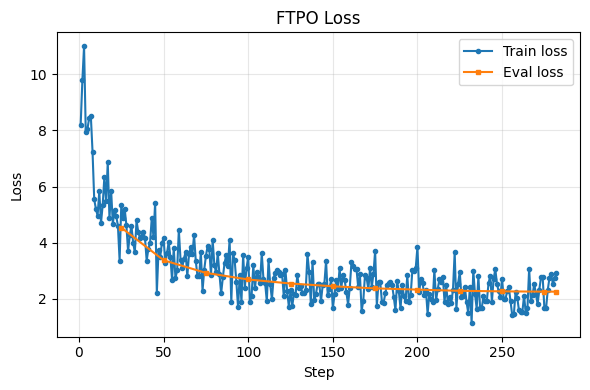

In [14]:
import matplotlib.pyplot as plt

log = ftpo_trainer.state.log_history

train_steps = [e["step"] for e in log if "loss" in e]
train_loss = [e["loss"] for e in log if "loss" in e]
eval_steps = [e["step"] for e in log if "eval_loss" in e]
eval_loss = [e["eval_loss"] for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(train_steps, train_loss, label="Train loss", marker="o", markersize=3)
if eval_loss:
    ax.plot(eval_steps, eval_loss, label="Eval loss", marker="s", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("FTPO Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate

Re-run generation on a few eval prompts and compare the base model (LoRA disabled) vs. the FTPO-trained model (LoRA enabled). The base model should doom-loop on most prompts, while the trained model should break out of doom loops.

In [15]:
from tqdm.auto import tqdm
from IPython.display import Markdown, display

# Before/after comparison
NUM_EVAL = 3
eval_prompts = [row["full_prompt"] for row in eval_dataset_ftpo.select(range(NUM_EVAL))]

# Pass 1: Base model (disable LoRA adapter)
print("🔍 Generating with base model (LoRA disabled)...")
before_results = []
lora_model.disable_adapter_layers()
for prompt in tqdm(eval_prompts, desc="Base model"):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(lora_model.device)
    with torch.no_grad():
        output = lora_model.generate(input_ids, max_new_tokens=4000, do_sample=False)
    text = tokenizer.decode(output[0][input_ids.shape[1]:], skip_special_tokens=True)
    found, hit = find_inner_repetition(text)
    before_results.append({"text": text, "doom": found, "snippet": hit.snippet if found else None})
lora_model.enable_adapter_layers()

# Pass 2: FTPO-trained model (LoRA enabled)
print("🔍 Generating with FTPO-trained model...")
after_results = []
for prompt in tqdm(eval_prompts, desc="FTPO model"):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(lora_model.device)
    with torch.no_grad():
        output = lora_model.generate(input_ids, max_new_tokens=4000, do_sample=False)
    text = tokenizer.decode(output[0][input_ids.shape[1]:], skip_special_tokens=True)
    found, hit = find_inner_repetition(text)
    after_results.append({"text": text, "doom": found, "snippet": hit.snippet if found else None})

# Summary table
before_doom = sum(r["doom"] for r in before_results)
after_doom = sum(r["doom"] for r in after_results)

rows = []
for i in range(NUM_EVAL):
    prompt_preview = eval_prompts[i][:80].replace("\n", " ").strip() + "..."
    b = "doom loop" if before_results[i]["doom"] else "clean"
    a = "doom loop" if after_results[i]["doom"] else "clean"
    rows.append(f"| {i+1} | {prompt_preview} | {b} | {a} |")

table = "\n".join([
    f"| # | Prompt | Before (base) | After (FTPO) |",
    "|---|--------|---------------|--------------|",
] + rows)

display(Markdown(table))

🔍 Generating with base model (LoRA disabled)...


Base model:   0%|          | 0/3 [00:00<?, ?it/s]

[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


🔍 Generating with FTPO-trained model...


FTPO model:   0%|          | 0/3 [00:00<?, ?it/s]

| # | Prompt | Before (base) | After (FTPO) |
|---|--------|---------------|--------------|
| 1 | Write Python code to solve the task. Make a program that takes a value (x) and r... | doom loop | clean |
| 2 | Create a table from the ideas, gourmet food ecommerce, student accommodation, sm... | doom loop | clean |
| 3 | Problem: the sum of three consecutive integers is 312 . what is the sum of the n... | doom loop | clean |

## Save merged model

Merge the extra weights learned with LoRA back into the model to obtain a "normal" model checkpoint.

In [ ]:
print("\n🔄 Merging LoRA weights...")
merged_model = lora_model.merge_and_unload()
merged_model.save_pretrained("./lfm2-antidoom-merged")
tokenizer.save_pretrained("./lfm2-antidoom-merged")
print("💾 Merged model saved to: ./lfm2-antidoom-merged")

# To push the merged model to the Hugging Face Hub, uncomment:
# merged_model.push_to_hub("your-model-path")
# tokenizer.push_to_hub("your-model-path")

## 📖 References:
- [Antidoom blog post](https://liquid.ai/blog/antidoom)
- [Antidoom GitHub repo](https://github.com/Liquid4All/antidoom)
- [FTPO / Antislop paper](https://huggingface.co/papers/2510.15061)
- [TRL: Change the training objective](https://huggingface.co/docs/trl/main/en/customization#change-the-training-objective)